# Visualizando cómo Aprende una CNN 🧠👁️  

## Objetivos  
1. Analizar cómo una **red convolucional (CNN)** interpreta una imagen y transforma la información visual en conocimiento.  
2. Comprender qué tipo de **características visuales** aprende el modelo al procesar imágenes del conjunto **MNIST**.  
3. Explorar técnicas de **visualización del aprendizaje** como los *saliency maps* para identificar las zonas más importantes de la imagen para el modelo.  



## Aprendizaje de una red  
Durante el entrenamiento, una **CNN aprende de manera progresiva y jerárquica**, pasando de lo simple a lo complejo.  
Las **primeras capas** actúan como detectores de patrones básicos 🎯 —aprenden a reconocer **bordes, líneas y contrastes**—, lo que equivale a que la red empiece a “ver” los contornos del número.  
Las **capas intermedias** combinan esos elementos para captar **formas más complejas**, como curvas o partes específicas de los dígitos (por ejemplo, el lazo del 8 o la base del 4).  
Finalmente, las **capas finales** reúnen toda esa información visual para **decidir a qué número corresponde la imagen**, basándose en las características aprendidas en los niveles anteriores.  
En conjunto, la red pasa de ver **píxeles aislados** a **conceptos visuales** cada vez más abstractos, hasta lograr una comprensión completa de la figura. 🧩✨  




### Saliency Maps  
Los **saliency maps** 🧠🔥 (o mapas de relevancia) son una forma de visualizar **en qué partes de la imagen se concentró la atención del modelo** durante la predicción.  
A través de ellos, podemos ver **qué píxeles o regiones fueron más influyentes** para que la red identificara un dígito.  
Por ejemplo, en una imagen del número *3*, el mapa puede resaltar los **bordes curvos** que diferencian este dígito de un *8* o un *5*.  
Esta herramienta nos ayuda a **interpretar el “por qué” detrás de las decisiones de la red**, brindando transparencia y una mejor comprensión de cómo la CNN realmente “ve” las imágenes. 👁️📊  

### Imagen de activación máxima 🌀  

La **imagen de activación máxima** representa la figura que hace que una neurona del modelo se active al máximo, es decir, la imagen que la red “reconoce” como el ejemplo ideal de una clase. 🧠✨  
En lugar de usar una imagen real, se parte de una imagen aleatoria (ruido) y se ajustan sus píxeles poco a poco para que la **neurona correspondiente a un dígito específico** responda con la mayor intensidad posible.  
El resultado es una representación visual de lo que la red “recuerda” o considera más característico para esa clase.  
Por ejemplo, en el caso de **MNIST**, la neurona del “3” generará una imagen con trazos curvos, mientras que la del “1” mostrará líneas rectas y verticales.  
Este tipo de visualización nos ayuda a **comprender cómo la red organiza su conocimiento interno** y qué tipo de patrones considera más representativos para cada categoría. 👁️🔢  


## Configuración del proyecto

### Cargar librerias

In [1]:
! pip install -q tensorflow numpy pillow gradio matplotlib || echo "Instalacion completa"


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import gradio as gr
from PIL import Image
import matplotlib.pyplot as plt
import io


### Entrenar modelo

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0
#Crear el modelo CNN con Keras
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 clases (dígitos 0–9)
])

# Compilar y entrenar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5,
                    validation_data=(X_test, y_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9042 - loss: 0.3171 - val_accuracy: 0.9838 - val_loss: 0.0469
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9854 - loss: 0.0473 - val_accuracy: 0.9875 - val_loss: 0.0362
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9900 - loss: 0.0298 - val_accuracy: 0.9899 - val_loss: 0.0289
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 0.9903 - val_loss: 0.0293
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9955 - loss: 0.0147 - val_accuracy: 0.9901 - val_loss: 0.0305


### Saliency Maps

In [4]:
def predecir_digito_con_saliency(image):
    try:
        if image is None:
            return "Por favor dibuja un número 🙃", None

        # Extraer imagen del sketchpad
        if isinstance(image, dict):
            img_array = image.get("composite", None)
            if img_array is None:
                return "⚠️ No se pudo obtener la imagen del input ('composite' vacío).", None
        else:
            return f"⚠️ Tipo de entrada no soportado: {type(image)}", None

        # Preprocesamiento de la imagen
        img_gray = np.array(img_array).astype(np.uint8)
        img_gray = 255 - img_gray  # Invertir colores (fondo negro)
        img = Image.fromarray(img_gray).resize((28, 28))
        arr = np.array(img) / 255.0
        arr = arr.reshape(1, 28, 28, 1)

        # 🔹 Convertir a tensor antes de pasar al modelo
        arr_tf = tf.convert_to_tensor(arr, dtype=tf.float32)

        # Predicción del modelo
        preds = model.predict(arr, verbose=0)
        pred_label = np.argmax(preds)
        pred_conf = np.max(preds)

        # 🔹 Calcular el saliency map con GradientTape
        with tf.GradientTape() as tape:
            tape.watch(arr_tf)
            preds_tf = model(arr_tf)
            loss = preds_tf[:, pred_label]

        grads = tape.gradient(loss, arr_tf)
        grads = tf.math.abs(grads)
        saliency = tf.reduce_max(grads, axis=-1)[0]

        # Normalizar mapa [0,1]
        saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) + 1e-8)
        saliency = saliency.numpy()

        # Convertir saliency map a imagen para mostrar
        plt.figure(figsize=(2.8, 2.8))
        plt.axis("off")
        plt.imshow(saliency, cmap="hot")
        buf = io.BytesIO()
        plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
        plt.close()
        buf.seek(0)
        saliency_img = Image.open(buf)

        texto = f"🧠 El modelo predice: {pred_label} (confianza: {pred_conf:.2f})"
        return texto, saliency_img

    except Exception as e:
        import traceback
        return f"⚠️ Error: {str(e)}\n\n{traceback.format_exc()}", None

In [5]:

# -----------------------------
# Interfaz Gradio
# -----------------------------
iface = gr.Interface(
    fn=predecir_digito_con_saliency,
    inputs=gr.Sketchpad(
        crop_size=(256, 256),
        type="numpy",
        image_mode="L",
        brush=gr.Brush(),
        label="Dibuja un número (0–9)"
    ),
    outputs=[
        gr.Textbox(label="Predicción del modelo"),
        gr.Image(label="Mapa de saliencia")
    ],
    title="🖍️ Dibuja un número y observa cómo piensa la red",
    description="La red convolucional predice el dígito y genera un saliency map que muestra qué partes influyeron más en su decisión."
)



In [6]:
iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f917beb21d04f8223.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Imagen máxima activacion

In [7]:
def _gaussian_kernel(size=5, sigma=1.0):
    """Kernel 2D gaussiano para un blur suave."""
    ax = tf.range(-size//2 + 1, size//2 + 1, dtype=tf.float32)
    xx, yy = tf.meshgrid(ax, ax)
    kernel = tf.exp(-(xx**2 + yy**2)/(2.0*sigma**2))
    kernel = kernel / tf.reduce_sum(kernel)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]  # [k,k,1,1]
    return kernel

def generar_imagen_activacion_mejorada(
    modelo,
    clase_objetivo: int,
    pasos: int = 250,
    tasa_aprendizaje: float = 8.0,
    l2_lambda: float = 1e-3,
    tv_lambda: float = 1e-2,
    blur_cada: int = 25,
    blur_sigma: float = 0.8,
    semilla: int = 42
):
    """
    Genera una imagen que maximiza la activación de 'clase_objetivo' con regularización.
    Pensado para MNIST (28x28x1, valores en [0,1]).
    """
    tf.random.set_seed(semilla)

    # 1) Inicializa cercano a fondo negro (MNIST) + pequeño ruido
    img = tf.zeros((1, 28, 28, 1), dtype=tf.float32) + 0.05*tf.random.uniform((1,28,28,1))

    # Kernel para blur suave
    gk = _gaussian_kernel(size=5, sigma=blur_sigma)

    for t in range(1, pasos+1):
        with tf.GradientTape() as tape:
            tape.watch(img)

            # 2) Forward y objetivo estable: log(prob) de la clase objetivo
            prob = modelo(img, training=False)                    # softmax
            obj_cls = tf.math.log(prob[0, clase_objetivo] + 1e-8) # evita saturación

            # 3) Regularizaciones
            l2_reg = tf.reduce_mean(tf.square(img))
            tv_reg = tf.reduce_mean(tf.image.total_variation(img))

            # 4) Función objetivo total (maximizar)
            objective = obj_cls - l2_lambda*l2_reg - tv_lambda*tv_reg

        # 5) Gradientes e incremento
        grad = tape.gradient(objective, img)
        grad = tf.math.l2_normalize(grad)
        step = (tasa_aprendizaje / (1.0 + 0.01*t))  # leve schedule
        img = img + step * grad

        # 6) Blur suave cada ciertos pasos para matar alta frecuencia
        if blur_cada and (t % blur_cada == 0):
            img = tf.nn.conv2d(img, gk, strides=1, padding="SAME")

        # 7) Mantener en rango válido
        img = tf.clip_by_value(img, 0.0, 1.0)

    return img[0, :, :, 0].numpy()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


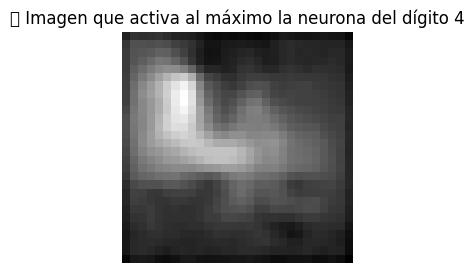

In [8]:
# ==== Ejemplo de uso ====
digito = 4  # cambia 0-9
imagen_act = generar_imagen_activacion_mejorada(
    model, clase_objetivo=digito,
    pasos=250, tasa_aprendizaje=9.0,
    l2_lambda=1e-3, tv_lambda=1e-2,
    blur_cada=25, blur_sigma=0.8
)

plt.figure(figsize=(3,3))
plt.imshow(imagen_act, cmap="gray")
plt.title(f"🌀 Imagen que activa al máximo la neurona del dígito {digito}")
plt.axis("off")
plt.show()